In [3]:
%load_ext autoreload
%autoreload 2

https://www.kaggle.com/code/lakshyamimani/mind-dataset-notebook-verv

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

Matplotlib is building the font cache; this may take a moment.


In [5]:
behavior = pd.read_csv('/Users/jessicakahn/Documents/repos/MIND/data/MINDsmall_train/behaviors.tsv',sep='\t', header=None)
news = pd.read_csv('/Users/jessicakahn/Documents/repos/MIND/data/MINDsmall_train/news.tsv',sep='\t',header=None)
news.columns = ['NewsID', 'Category', 'SubCategory', 'Title', 'Abstract', 'URL', 'TitleEntities', 'AbstractEntities']
behavior.columns = ['ImpressionID', 'UserID', 'Time', 'History', 'Impressions']

In [6]:
news['Abstract'] = news['Abstract'].fillna('')
news['text_features'] = news['Title'] + " " + news['Abstract']

In [85]:
behavior['history_list'] = behavior['History'].str.split(" ")

In [99]:
# behavior.head(2)


In [87]:
behavior['history_len'] = behavior['history_list'].str.len()

<Axes: >

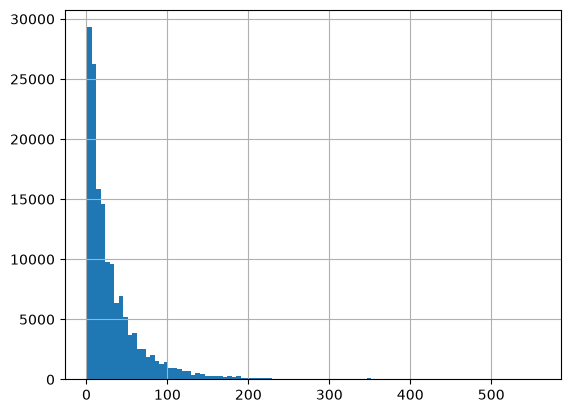

In [90]:
behavior['history_len'].hist(bins=100)

In [92]:
behavior[behavior['history_len']>=3].shape[0]/behavior.shape[0]

0.9420571464976268

In [96]:
behavior['hist3'] = behavior['history_list'].str[-3:]

In [8]:

news.head(2)

,NewsID,Category,SubCategory,Title,Abstract,URL,TitleEntities,AbstractEntities,text_features
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],"The Brands Queen Elizabeth, Prince Charles, an..."
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...",50 Worst Habits For Belly Fat These seemingly ...


In [9]:
# parse_impressions.py
import pandas as pd

# Parse a single impressions string into a DataFrame
def parse_impressions(impressions_str):
    items = impressions_str.split()
    rows = []
    for item in items:
        article_id, clicked = item.rsplit("-", 1)
        rows.append({
            "article_id": article_id,
            "clicked": int(clicked)
        })
    return pd.DataFrame(rows)


# Apply across a full MIND DataFrame
# df has columns: impression_id, user_id, time, history, impressions
exploded = (
    behavior.assign(
        impression=behavior["Impressions"].str.split()
    )
    .explode("impression")
    .assign(
        article_id=lambda x: x["impression"].str.rsplit("-", n=1).str[0],
        clicked=lambda x: x["impression"].str.rsplit("-", n=1).str[1].astype(int)
    )
    .drop(columns=["impression"])
    .reset_index(drop=True)
)

In [10]:
exploded.head()

,ImpressionID,UserID,Time,History,Impressions,article_id,clicked
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,N55689,1
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,N35729,0
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N20678,0
3,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N39317,0
4,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N58114,0


In [36]:
# print(exploded[exploded['UserID']=='U13740'].shape, exploded[exploded['UserID']=='U13740']['clicked'].sum())
# exploded[exploded['UserID']=='U13740']
plot_clicks = exploded.groupby('UserID')['clicked'].sum().reset_index()
# plot_clicks.head()
# plt.hist(plot_clicks['clicked'], bins=30, edgecolor='black')
plot_clicks[plot_clicks['clicked']>=5].shape

(16159, 2)

In [11]:
exploded['history'] = exploded["History"].str.split()

from https://github.com/daconjam/detecting-gender-bias/blob/main/bias/code/MIND.ipynb

In [12]:
female = ['goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam', 
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress', 
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives', 
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses', 
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess', 
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses', 
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood', 
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny', 
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandniece', 'grandnieces', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers']
male = ['god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons', 
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor', 
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir', 
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers', 
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags', 
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle', 
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother', 
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl', 
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster', 
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal', 
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight', 
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps']


In [13]:
gender_words  = len(female) + len(male)
print('The total no. of gender words are', gender_words)
print('There are {0} male words, and {1} female words'.format(len(male), len(female)))

The total no. of gender words are 465
There are 230 male words, and 235 female words


In [ ]:
len(news['Abstract'])
news['Abstract'] = news['Abstract'].apply(str) # ensures the sentences are strings
news['Abstract'] = news['Abstract'].str.lower() # make the abstract lowercase 

51282

In [16]:
# Here we count the male and female gender words in each abstract and 
# determine a specific gender tag per abstract

m_dict, f_dict = {}, {}

for index, line in enumerate(news['Abstract']):
    words = line.split() 
    
    m, f = 0, 0  #counters for male and female words 
    
    for w in words:
        if w in male: #checks into list of male words 
            m += 1 
            if w in m_dict: #counts the male words in the abstracts
                m_dict[w] += 1
            else:
                m_dict[w] = 1
        
            
        elif w in female: #checks into list of female words 
            f += 1
            if w in f_dict: #counts the male words in the abstracts
                f_dict[w] += 1
            else:
                f_dict[w] = 1
            
    # Here we determine the tags of the abstracts        
    if m > f:
        news.loc[index, 'Gender'] = 'M'
        
    elif m == f:
        news.loc[index, 'Gender'] = 'Neutral'
        
    elif f > m:
        news.loc[index, 'Gender'] = 'F'

In [18]:
# sorted(m_dict.items(), key=lambda x: x[1], reverse=True)

In [20]:
news.head(2)

,NewsID,Category,SubCategory,Title,Abstract,URL,TitleEntities,AbstractEntities,text_features,Gender
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],"The Brands Queen Elizabeth, Prince Charles, an...",Neutral
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...",50 Worst Habits For Belly Fat These seemingly ...,Neutral


In [28]:
# news[news['NewsID']=='N55689']

In [ ]:
# Retrieval uses vector store, then input text to LLM for reranking

In [ ]:
import torch

In [ ]:
embeddings = np.load('data/mind_abstract_embeddings.npy', allow_pickle=True)

In [71]:
news["text_to_embed"] = "Title: " + news["Title"] + " | Abstract: " + news["Abstract"]

In [ ]:
X = torch.tensor(embeddings, dtype=torch.float32)

In [49]:
class SAE(nn.Module):
    def __init__(self, d_in, d_latent):
        super().__init__()
        self.enc = nn.Linear(d_in, d_latent, bias=True)
        self.dec = nn.Linear(d_latent, d_in, bias=False)  # bias often dropped here
        self._normalize_decoder()

    def _normalize_decoder(self):
        with torch.no_grad():
            self.dec.weight.div_(self.dec.weight.norm(dim=0, keepdim=True) + 1e-8)

    def forward(self, x):
        latent = torch.relu(self.enc(x))
        recon = self.dec(latent)
        return recon, latent

class TopKSAE(nn.Module):
    def __init__(self, d_in, d_latent, k):
        super().__init__()
        self.enc = nn.Linear(d_in, d_latent, bias=True)
        self.dec = nn.Linear(d_latent, d_in, bias=False)
        self.k = k
        self._normalize_decoder()

    def _normalize_decoder(self):
        with torch.no_grad():
            self.dec.weight.div_(self.dec.weight.norm(dim=0, keepdim=True) + 1e-8)

    def forward(self, x):
        pre_act = self.enc(x)
        topk_vals, topk_idx = torch.topk(pre_act, self.k, dim=-1)
        latent = torch.zeros_like(pre_act)
        latent.scatter_(-1, topk_idx, torch.relu(topk_vals))
        recon = self.dec(latent)
        return recon, latent


In [59]:
k = 64  # try 16, 32, 64 and compare — this is your main tuning knob now
d_in = embeddings.shape[1]
d_latent = d_in * 8
sae = TopKSAE(d_in, d_latent, k=k)
opt = torch.optim.Adam(sae.parameters(), lr=1e-3)

recon_loss_list = []
for epoch in range(200):
    perm = torch.randperm(X.shape[0])
    total_recon = 0
    n_batches = 0
    for i in range(0, X.shape[0], 256):
        batch = X[perm[i:i+256]]
        recon, latent = sae(batch)
        recon_loss = ((recon - batch) ** 2).mean()

        opt.zero_grad()
        recon_loss.backward()
        opt.step()
        sae._normalize_decoder()

        total_recon += recon_loss.item()
        n_batches += 1
    print(f"epoch {epoch}: recon={total_recon/n_batches:.8f}")
    recon_loss_list.append(total_recon/n_batches)

epoch 0: recon=0.00136203
epoch 1: recon=0.00074059
epoch 2: recon=0.00066253
epoch 3: recon=0.00062156
epoch 4: recon=0.00059278
epoch 5: recon=0.00057058
epoch 6: recon=0.00055210
epoch 7: recon=0.00053569
epoch 8: recon=0.00052142
epoch 9: recon=0.00050809
epoch 10: recon=0.00049606
epoch 11: recon=0.00048467
epoch 12: recon=0.00047384
epoch 13: recon=0.00046417
epoch 14: recon=0.00045507
epoch 15: recon=0.00044690
epoch 16: recon=0.00043945
epoch 17: recon=0.00043234
epoch 18: recon=0.00042570
epoch 19: recon=0.00041967
epoch 20: recon=0.00041428
epoch 21: recon=0.00040931
epoch 22: recon=0.00040478
epoch 23: recon=0.00040069
epoch 24: recon=0.00039693
epoch 25: recon=0.00039350
epoch 26: recon=0.00039031
epoch 27: recon=0.00038733
epoch 28: recon=0.00038464
epoch 29: recon=0.00038209
epoch 30: recon=0.00037957
epoch 31: recon=0.00037748
epoch 32: recon=0.00037549
epoch 33: recon=0.00037356
epoch 34: recon=0.00037182
epoch 35: recon=0.00037014
epoch 36: recon=0.00036860
epoch 37: r

In [60]:
print("k = ",k)
with torch.no_grad():
    recon, latent = sae(X)
    mse = ((recon - X) ** 2).mean()
    baseline_mse = (X ** 2).mean()  # error if you just predicted the zero vector
    nmse = mse / baseline_mse
    print(f"NMSE: {nmse:.4f}")
fve = 1 - nmse
print(f"Fraction of variance explained: {fve:.4f}")

k =  64
NMSE: 0.1218
Fraction of variance explained: 0.8782


In [62]:
sae.eval()
with torch.no_grad():
    _, all_latents = sae(X)
all_latents = all_latents.numpy() 

In [48]:
with torch.no_grad():
    _, latent = sae(X[:1000])  # sample batch
nonzero = latent[latent > 0]
print(f"mean nonzero activation: {nonzero.mean().item():.6f}")
print(f"median nonzero activation: {nonzero.median().item():.6f}")
print(f"fraction > 0.01: {(latent > 0.01).float().mean().item():.4f}")
print(f"fraction > 0.1:  {(latent > 0.1).float().mean().item():.4f}")

mean nonzero activation: 0.016419
median nonzero activation: 0.013612
fraction > 0.01: 0.2269
fraction > 0.1:  0.0011


In [64]:
print(news['Gender'].unique())
print(news['Gender'].value_counts(dropna=False))

<StringArray>
['Neutral', 'M', 'F']
Length: 3, dtype: str
Gender
Neutral    37576
M          10281
F           3425
Name: count, dtype: int64


In [67]:
from sklearn.metrics import roc_auc_score
import numpy as np

labels = np.array(news['Gender'])
classes = ["M", "F", "Neutral"]

auroc_scores = {}  # {class: array of shape (d_latent,)}
min_support = 30  # tune based on your dataset size — e.g. ~0.05% of 51,282

for cls in classes:
    y_binary = (labels == cls).astype(int)
    scores = np.full(all_latents.shape[1], np.nan)  # NaN default, not zero
    for j in range(all_latents.shape[1]):
        col = all_latents[:, j]
        n_active = (col > 0).sum()
        if col.std() == 0 or n_active < min_support:
            continue
        scores[j] = roc_auc_score(y_binary, col)
    auroc_scores[cls] = scores

for cls in classes:
    scores = auroc_scores[cls]
    valid_idx = np.where(~np.isnan(scores))[0]
    ranked = valid_idx[np.argsort(-np.abs(scores[valid_idx] - 0.5))][:15]
    print(f"\nTop latents predicting '{cls}':")
    for idx in ranked:
        n_active = (all_latents[:, idx] > 0).sum()
        print(f"  latent {idx}: AUROC={scores[idx]:.3f}  (fires on {n_active}/{len(all_latents)})")


Top latents predicting 'M':
  latent 1199: AUROC=0.749  (fires on 19217/51282)
  latent 2002: AUROC=0.375  (fires on 21486/51282)
  latent 2072: AUROC=0.384  (fires on 12726/51282)
  latent 2541: AUROC=0.585  (fires on 3696/51282)
  latent 780: AUROC=0.580  (fires on 19265/51282)
  latent 1521: AUROC=0.576  (fires on 15760/51282)
  latent 2322: AUROC=0.429  (fires on 14042/51282)
  latent 2657: AUROC=0.571  (fires on 14043/51282)
  latent 2642: AUROC=0.571  (fires on 14263/51282)
  latent 1646: AUROC=0.568  (fires on 13045/51282)
  latent 934: AUROC=0.437  (fires on 14057/51282)
  latent 817: AUROC=0.438  (fires on 11020/51282)
  latent 2140: AUROC=0.441  (fires on 13222/51282)
  latent 2928: AUROC=0.444  (fires on 13737/51282)
  latent 2043: AUROC=0.552  (fires on 9839/51282)

Top latents predicting 'F':
  latent 2140: AUROC=0.951  (fires on 13222/51282)
  latent 1442: AUROC=0.641  (fires on 2406/51282)
  latent 1820: AUROC=0.632  (fires on 8222/51282)
  latent 1521: AUROC=0.625  (fi

In [82]:
for idx in ranked[:15]:
    n_active = (all_latents[:, idx] > 0).sum()
    print(f"latent {idx}: fires on {n_active} / {len(all_latents)} articles")

latent 1199: fires on 19217 / 51282 articles
latent 2002: fires on 21486 / 51282 articles
latent 1521: fires on 15760 / 51282 articles
latent 2140: fires on 13222 / 51282 articles
latent 2072: fires on 12726 / 51282 articles
latent 817: fires on 11020 / 51282 articles
latent 2322: fires on 14042 / 51282 articles
latent 934: fires on 14057 / 51282 articles
latent 2541: fires on 3696 / 51282 articles
latent 2207: fires on 19092 / 51282 articles
latent 1820: fires on 8222 / 51282 articles
latent 978: fires on 19125 / 51282 articles
latent 2928: fires on 13737 / 51282 articles
latent 2657: fires on 14043 / 51282 articles
latent 1646: fires on 13045 / 51282 articles


In [83]:
def top_activating_articles(all_latents, latent_idx, abstracts, labels, k=15):
    activations = all_latents[:, latent_idx]
    top_idx = np.argsort(-activations)[:k]
    for i in top_idx:
        print(f"[{labels[i]}] act={activations[i]:.4f}  {abstracts[i][:120]}")

top_activating_articles(all_latents, 1442, news["text_to_embed"].to_list(), labels)

[Neutral] act=0.3079  Title: What Menopause Does to Women's Brains | Abstract: Two-thirds of Alzheimer's patients are women. My foggy 53-year-
[Neutral] act=0.2939  Title: There were never more women in UK Parliament. Now there's an exodus | Abstract: A growing number of British lawma
[F] act=0.2817  Title: Annual Women In Business Forum 2019 Highlights Overcoming Entrepreneurial Challenges | Abstract: The panel discus
[Neutral] act=0.2661  Title: 70 Gifts For Women That Won't Break the Bank | Abstract: Women can be hard to shop for sometimes, so we've curate
[Neutral] act=0.2657  Title: Drawn by the Salary, Women Flock to Trucking | Abstract: Truck drivers typically are paid by the mile, regardless
[Neutral] act=0.2613  Title: Young Northeast Florida fans flock to U.S. women's soccer | Abstract: When the U.S. women's national soccer team 
[F] act=0.2613  Title: Live updates: UConn women open their season vs. Cal | Abstract: Follow along for live updates from Gampel Pavilio
[M] act=0.2

In [ ]:
top_candidates = [2140, 1199, 1521, 780, 2002]
for idx in top_candidates:
    print(idx, all_latents[:, idx].std())

corr_matrix = np.corrcoef(all_latents[:, top_candidates].T)
print(corr_matrix)

2140 0.08125323
1199 0.06420342
1521 0.086676754
780 0.14397787
2002 0.07502444
[[ 1.         -0.02036249  0.14278199 -0.17190833 -0.02471318]
 [-0.02036249  1.         -0.02592375  0.09531345 -0.09492044]
 [ 0.14278199 -0.02592375  1.         -0.21615478 -0.05022131]
 [-0.17190833  0.09531345 -0.21615478  1.          0.02053861]
 [-0.02471318 -0.09492044 -0.05022131  0.02053861  1.        ]]


In [78]:
top_idx_for_latent_2140 = np.argsort(-all_latents[:, 2140])[:50]  # top 50 activating articles

pd.crosstab(news['Category'].iloc[top_idx_for_latent_2140], labels[top_idx_for_latent_2140])

col_0,F,Neutral
Category,,
entertainment,3,0
finance,0,1
health,1,1
lifestyle,2,0
movies,2,1
music,4,1
news,16,1
sports,7,3
tv,4,0


In [79]:
top50 = news.iloc[top_idx_for_latent_2140].copy()
top50['activation'] = all_latents[top_idx_for_latent_2140, 2140]
top50[labels[top_idx_for_latent_2140] == "Neutral"][['Title', 'Abstract', 'activation']] if 'Title' in top50.columns else None

,Title,Abstract,activation
4249,Marie Osmond's photo flashback,Take a look back at the life of Marie Osmond!,0.429919
30918,Two female astronauts are making history. How ...,This is NASA astronauts Christina Koch's fourt...,0.429553
42983,Miss North Carolina Contestant Madeline Delp S...,When you're able to look your fears in the fac...,0.428056
28852,Getting to know recent UConn women's basketbal...,"Growing up, Aaliyah Edwards always looked up t...",0.419111
16280,Eustis woman wins big after buying $30 scratch...,,0.416103
14173,Michelle Pfeiffer initially blamed herself aft...,Michelle Pfeiffer is opening up about an uncom...,0.414400
21365,Iowa State Women's Basketball: Kristin Scott's...,The Iowa State women's basketball season gets ...,0.412883
9308,Tennis champion Maria Sharapova on overcoming ...,ABC News' Rebecca Jarvis sat down with tennis ...,0.411452


In [80]:
steering_vec_2140 = sae.dec.weight[:, 2140].detach().numpy()

In [ ]:
# steering_vec_2140.shape

(384,)

## Retrieval

In [105]:
import chromadb
client = chromadb.PersistentClient(path="../mind_chroma_db")
collection = client.get_collection(name="mind_news")
# collections = client.list_collections()

In [171]:
news.head(1)

,NewsID,Category,SubCategory,Title,Abstract,URL,TitleEntities,AbstractEntities,text_features,Gender,text_to_embed,rec_list,rec_list_,gender_list
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],"The Brands Queen Elizabeth, Prince Charles, an...",Neutral,"Title: The Brands Queen Elizabeth, Prince Char...","[[N13548, N55528, N11658, N7335, N30132, N3635...","[N13548, N55528, N11658, N7335, N30132, N36352...","[Neutral, Neutral, Neutral, Neutral, Neutral, ..."


In [141]:
behavior.head(1)

,ImpressionID,UserID,Time,History,Impressions,history_list,history_len,hist3
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,"[N55189, N42782, N34694, N45794, N18445, N6330...",9.0,"[N10414, N19347, N31801]"


In [146]:
gender_dict = news.set_index('NewsID')['Gender'].to_dict()

In [148]:
# gender_dict

In [125]:
test_hist = behavior.iloc[0]['hist3']
# df.loc[df['Filter_Column'] > 15, 'Target_Column'].tolist()
test_abstracts = news.loc[news['NewsID'].isin(test_hist),'Abstract'].tolist()


In [183]:
behavior.to_csv('../data/behavior_processed.csv',index=False)

In [132]:
# test_abstracts
news.loc[news['NewsID'].isin(test_hist),'Gender'].tolist()

['Neutral', 'F', 'M']

In [154]:
collection.query(
    query_texts=test_abstracts[0]
)['ids'][0]

['N29993',
 'N31801',
 'N19522',
 'N34069',
 'N628',
 'N5035',
 'N33257',
 'N9021',
 'N2917',
 'N48248']

In [155]:
# test_output['ids']
# [news.loc[news['NewsID']==i,'Gender'] for i in test_output['ids'][0]]

In [160]:
# Calculate list of closest item for each item in news and append to column
news['rec_list'] = news.apply(lambda row: collection.query(query_texts=row['Abstract']),axis=1).str['ids']

In [168]:
news['rec_list_'] = news['rec_list'].str[0]

In [170]:
news['gender_list'] = news['rec_list_'].apply(lambda x: [gender_dict[i] for i in x])


In [172]:
news['rec_count_neut'] = news['gender_list'].apply(lambda x: x.count('Neutral'))
news['rec_count_male'] = news['gender_list'].apply(lambda x: x.count('M'))
news['rec_count_female'] = news['gender_list'].apply(lambda x: x.count('F'))

In [174]:
news.groupby('Gender')[['rec_count_neut','rec_count_male','rec_count_female']].sum()

,rec_count_neut,rec_count_male,rec_count_female
Gender,,,
F,15056,3570,15624
M,48632,50859,3319
Neutral,320911,42565,12284


In [175]:
news['Gender'].value_counts()

Gender
Neutral    37576
M          10281
F           3425
Name: count, dtype: int64

In [182]:
news.to_csv('../data/news_processed.csv')

The current setup only recommends on a single article - but we can update this to create a user vector - for example, average the embeddings of the user's history, or do a recency weight and then compare that vector to the database instead.

In [177]:
# Plot t-sne on embeddings 
import chromadb
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# client = chromadb.PersistentClient(path="./mind_chroma_db")
# collection = client.get_collection("mind_news")

result = collection.get(include=["embeddings"])
ids = result["ids"]
embeddings = result["embeddings"]

# join gender via your external dict, using the Chroma ID as the key
labels = [gender_dict.get(_id, "Unknown") for _id in ids]

# sanity check: make sure IDs actually line up
missing = sum(1 for l in labels if l == "Unknown")
print(f"{missing} / {len(ids)} IDs had no gender match")

0 / 51282 IDs had no gender match


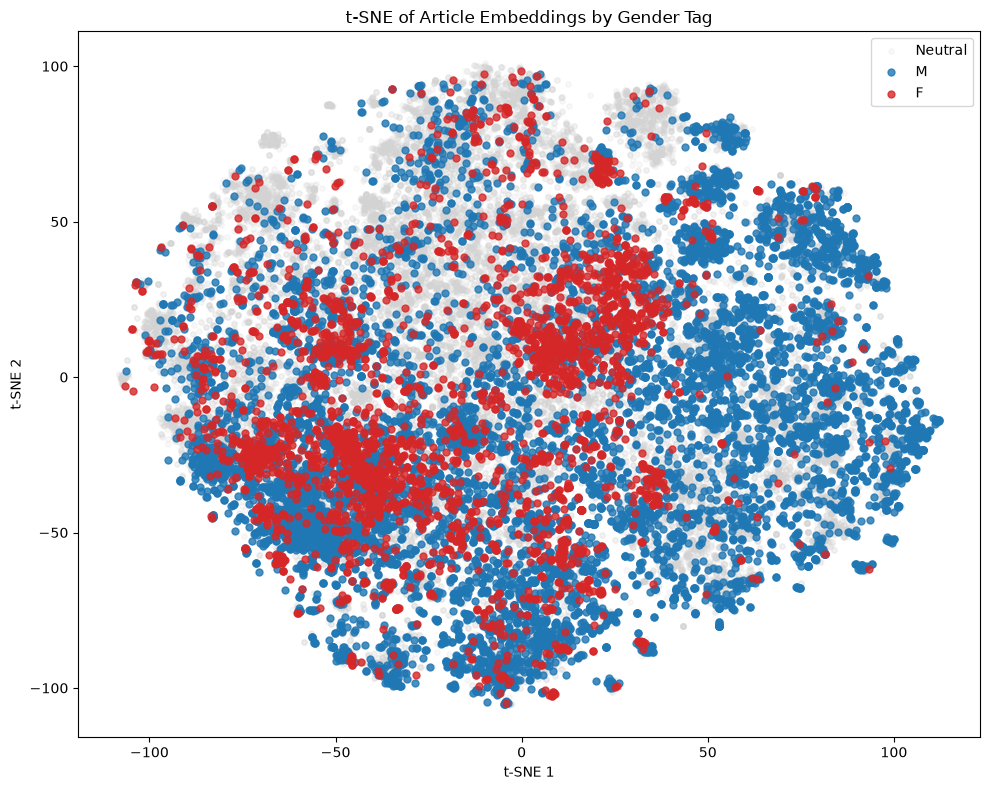

In [179]:
X = np.array(embeddings)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", metric="cosine")
X_2d = tsne.fit_transform(X)

# per-label styling
style_map = {
    "Neutral": {"color": "lightgray", "alpha": 0.15, "size": 15},
    "M":       {"color": "tab:blue",  "alpha": 0.8,  "size": 25},
    "F":       {"color": "tab:red",   "alpha": 0.8,  "size": 25},
}

plt.figure(figsize=(10, 8))

# plot in this specific order so Neutral sits underneath
for label in ["Neutral", "M", "F"]:
    style = style_map[label]
    idx = [i for i, l in enumerate(labels) if l == label]
    if idx:
        plt.scatter(X_2d[idx, 0], X_2d[idx, 1],
                    c=style["color"], alpha=style["alpha"], s=style["size"],
                    label=label)

plt.legend()
plt.title("t-SNE of Article Embeddings by Gender Tag")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig("tsne_gender.png", dpi=150)
plt.show()